In [3]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer
import ast
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score, recall_score, accuracy_score
import itertools
from collections import Counter
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)


Let's grab our dataframe from our EDA script:

In [4]:
df_clash = pd.read_pickle("../data/clash_royale_to_model.pkl")
cards = pd.read_csv("../data/cards.csv")

We know beforehand that some cards are strong individually, and other cards require "partner" cards to perform well. As such, the connections between cards will be nonlinear. There is no set size group which we know is the best to analyze.

For these reasons, a Decision Tree classifier is a strong choice, as we are working with non-linearly separable data in a supervised learning problem. We will elect to go with XGBoost.

Let's drop the columns that might cause leakage. We don't want the model to memorize strong players, or players that play in strong clans, so we will drop those features irrelevant to our problem.

In [6]:
def make_long(df: pd.DataFrame) -> pd.DataFrame:
    # winners
    w = pd.DataFrame({
        "battleTime": df["battleTime"],
        "arena.id": df["arena.id"],
        "gameMode.id": df["gameMode.id"],
        "startingTrophies.p": df["winner.startingTrophies"],
        "startingTrophies.o": df["loser.startingTrophies"],
        "trophyChange.p": df["winner.trophyChange"],
        "trophyChange.o": df["loser.trophyChange"],
        "elixir.p": df["winner.elixir.average"],
        "elixir.o": df["loser.elixir.average"],
        "total_level.p": df["winner.totalcard.level"],
        "total_level.o": df["loser.totalcard.level"],
        "troop_count.p": df["winner.troop.count"],
        "troop_count.o": df["loser.troop.count"],
        "spell_count.p": df["winner.spell.count"],
        "spell_count.o": df["loser.spell.count"],
        "structure_count.p": df["winner.structure.count"],
        "structure_count.o": df["loser.structure.count"],
        "cards.p": df["winner.cards.list"], #cards for this player
        "cards.o": df["loser.cards.list"], #cards for the opponent
        "y": 1
    })

    # losers
    l = pd.DataFrame({
        "battleTime": df["battleTime"],
        "arena.id": df["arena.id"],
        "gameMode.id": df["gameMode.id"],
        "startingTrophies.p": df["loser.startingTrophies"],
        "startingTrophies.o": df["winner.startingTrophies"],
        "trophyChange.p": df["loser.trophyChange"],
        "trophyChange.o": df["winner.trophyChange"],
        "elixir.p": df["loser.elixir.average"],
        "elixir.o": df["winner.elixir.average"],
        "total_level.p": df["loser.totalcard.level"],
        "total_level.o": df["winner.totalcard.level"],
        "troop_count.p": df["loser.troop.count"],
        "troop_count.o": df["winner.troop.count"],
        "spell_count.p": df["loser.spell.count"],
        "spell_count.o": df["winner.spell.count"],
        "structure_count.p": df["loser.structure.count"],
        "structure_count.o": df["winner.structure.count"],
        "cards.p": df["loser.cards.list"], #cards for this player
        "cards.o": df["winner.cards.list"], #cards for the opponent
        "y": 0
    })

    out = pd.concat([w, l], ignore_index=True)
    return out

Now, we use multi-hot encoding to encode our decks. This is because we will have eight cards on each player's deck vector that are in their deck, so we cannot use one-hot encoding.

Below, we characterize a class DeckBinarizer that will allow us to multi-hot encode the player's decks (do relevant operations).

In [7]:
id_to_name = dict(zip(cards["card_id"], cards["card_name"]))

class DeckBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, colname: str, prefix: str, id_to_name: dict = None):
        self.colname = colname
        self.prefix = prefix
        self.id_to_name = id_to_name
        self.mlb = MultiLabelBinarizer(sparse_output=True)

    def fit(self, X, y=None):
        self.mlb.fit(X[self.colname])
        return self

    def transform(self, X):
        M = self.mlb.transform(X[self.colname])
        return M

    def get_feature_names_out(self, input_features=None):
        feature_names = []
        for card_id in self.mlb.classes_:
            if self.id_to_name is not None:
                card_name = self.id_to_name.get(card_id, str(card_id))
            else:
                card_name = str(card_id)
            feature_names.append(f"{self.prefix}{card_name}")
        return np.array(feature_names, dtype=object)

Now, let's train the model!

In [8]:
# Keep only higher arenas (configurable) before the time-based split.
# This integrates with the existing pipeline without changing downstream feature logic.
USE_HIGH_ARENAS_ONLY = True
HIGH_ARENA_QUANTILE = 0.75  # top 25% arenas by arena.id

# Keep only most common game mode (configurable)
USE_MOST_COMMON_GAMEMODE_ONLY = True

df_model = df_clash.copy()

if USE_HIGH_ARENAS_ONLY:
    arena_numeric = pd.to_numeric(df_clash["arena.id"], errors="coerce")
    arena_cutoff = int(arena_numeric.quantile(HIGH_ARENA_QUANTILE))
    df_model = df_clash.loc[arena_numeric >= arena_cutoff].copy()
    print(f"[arena filter] cutoff arena.id >= {arena_cutoff}")
    print(f"[arena filter] rows: {len(df_clash):,} -> {len(df_model):,}")
    print("[arena filter] arenas kept:", sorted(df_model["arena.id"].dropna().unique())[:10], "...")

if USE_MOST_COMMON_GAMEMODE_ONLY:
    top_mode = df_model["gameMode.id"].mode().iloc[0]
    before = len(df_model)
    df_model = df_model.loc[df_model["gameMode.id"] == top_mode].copy()
    print(f"[mode filter] keeping most common gameMode.id = {top_mode}")
    print(f"[mode filter] rows: {before:,} -> {len(df_model):,}")

# Sort by battle time to reduce temporal leakage from changing metas.
df_sorted = df_model.sort_values("battleTime").reset_index(drop=True)
split_idx = int(0.8 * len(df_sorted))

train_battles = df_sorted.iloc[:split_idx]
test_battles  = df_sorted.iloc[split_idx:]

train_df = make_long(train_battles)
test_df  = make_long(test_battles)

def ensure_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []

train_df["cards.p"] = train_df["cards.p"].map(ensure_list)
train_df["cards.o"] = train_df["cards.o"].map(ensure_list)
test_df["cards.p"] = test_df["cards.p"].map(ensure_list)
test_df["cards.o"] = test_df["cards.o"].map(ensure_list)

y_train = train_df["y"].astype(int)
y_test  = test_df["y"].astype(int)

# Drop non-feature cols
X_train = train_df.drop(columns=["y", "battleTime", "battle_id"], errors="ignore")
X_test  = test_df.drop(columns=["y", "battleTime", "battle_id"], errors="ignore")

cat_cols = []
# Use arena as categorical feature only if it has >1 unique value in training data
if "arena.id" in X_train.columns and X_train["arena.id"].nunique(dropna=True) > 1:
    cat_cols = ["arena.id"]

num_cols = [
    "startingTrophies.p","startingTrophies.o",
    "elixir.p","elixir.o",
    "total_level.p","total_level.o",
    "spell_count.p","spell_count.o",
    "structure_count.p","structure_count.o",
]

transformers = []

if cat_cols:
    transformers.append(("cats", OneHotEncoder(handle_unknown="ignore"), cat_cols))

transformers.extend([
    ("nums", "passthrough", num_cols),
    ("deck_p", DeckBinarizer("cards.p", "", id_to_name), ["cards.p"]),
    ("deck_o", DeckBinarizer("cards.o", "", id_to_name), ["cards.o"]),
])

preprocess = ColumnTransformer(transformers=transformers, remainder="drop")

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state = 1
)

pipe = Pipeline([
    ("prep", preprocess),
    ("xgb", model),
])

pipe.fit(X_train, y_train)


[arena filter] cutoff arena.id >= 54000050
[arena filter] rows: 2,823,527 -> 2,677,249
[arena filter] arenas kept: [np.float64(54000050.0)] ...
[mode filter] keeping most common gameMode.id = 72000201.0
[mode filter] rows: 2,677,249 -> 1,727,575


,steps,"[('prep', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('deck_p', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
proba = pipe.predict_proba(X_test)[:, 1] #Extracts predicted win probabilities from model
pred = (proba >= 0.5).astype(int) #binarizes win = 1, loss = 0

print("Baseline win rate:", y_test.mean())
print("AUC:", roc_auc_score(y_test, proba)) #Here we measure the likelihood a winning deck was ranked above a losing deck
print("Acc:", accuracy_score(y_test, pred))

Baseline win rate: 0.5
AUC: 0.6375081523374685
Acc: 0.5965356062689029


As our Area Under the Curve (AUC) is 0.61 > 0.5, we have reason to believe that our model performs better than a random guess. It is important to note that although our AUC and Accuracy scores are not high, this is to be expected, because player skill plays a very large factor in game outcomes, although we don't have data on that.

Now we find feature importance.

In [10]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["xgb"].feature_importances_

fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True))

# Player and Opponent card-only importance
player_cards = fi[fi["feature"].astype(str).str.startswith("deck_p__")].copy()
opp_cards = fi[fi["feature"].astype(str).str.startswith("deck_o__")].copy()

print("\nTop 15 PLAYER deck card features:")
display(player_cards.head(15))

print("\nTop 15 OPPONENT deck card features:")
display(opp_cards.head(15))


Top 15 PLAYER deck card features:


,feature,importance
3,deck_p__Elixir Golem,0.013944
5,deck_p__Minion Horde,0.011187
7,deck_p__Mirror,0.010393
10,deck_p__Wizard,0.010051
11,deck_p__Bomb Tower,0.007697
12,deck_p__Goblin Barrel,0.007672
13,deck_p__Night Witch,0.007345
16,deck_p__Lava Hound,0.006960
18,deck_p__P.E.K.K.A,0.006934
22,deck_p__Barbarian Barrel,0.006723



Top 15 OPPONENT deck card features:


,feature,importance
2,deck_o__Elixir Golem,0.015044
4,deck_o__Minion Horde,0.011702
6,deck_o__Wizard,0.010718
9,deck_o__Mirror,0.010145
14,deck_o__The Log,0.007332
15,deck_o__Lava Hound,0.007096
17,deck_o__Goblin Barrel,0.006947
19,deck_o__Bomb Tower,0.006899
20,deck_o__Night Witch,0.006868
21,deck_o__P.E.K.K.A,0.006802


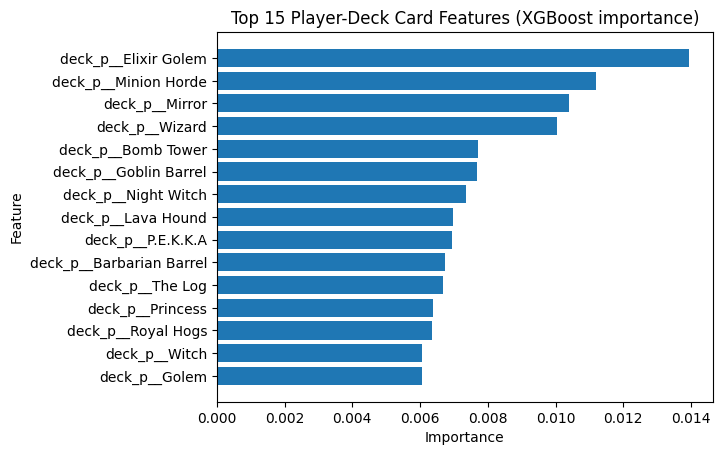

In [11]:
topN = 15
top_plot = player_cards.head(topN).iloc[::-1]  # reverse for nice barh

plt.figure()
plt.barh(top_plot["feature"].astype(str), top_plot["importance"])
plt.title(f"Top {topN} Player-Deck Card Features (XGBoost importance)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

It's important to note that feature importance does not indicate a positive effect.


Top 25 high-lift pairs (min_count=2000) in PLAYER decks:


,cardA,cardB,count,win_rate,lift
0,Barbarian Hut,Mega Minion,2103,0.544936,1.089872
1,Goblins,Lightning,2328,0.544674,1.089347
2,Elixir Collector,Hunter,2214,0.542909,1.085818
3,Barbarian Barrel,Elixir Collector,3504,0.540240,1.080479
4,Royal Ghost,Three Musketeers,2972,0.539367,1.078735
5,Goblin Hut,Skeleton Dragons,2107,0.538681,1.077361
6,Barbarian Barrel,Three Musketeers,4007,0.536561,1.073122
7,Bandit,Three Musketeers,4402,0.535666,1.071331
8,Bandit,Rascals,2212,0.534810,1.069620
9,Dark Prince,Three Musketeers,2504,0.534345,1.068690



Top 25 by unconventional_score (rare + strong)


,cardA,cardB,count,support,win_rate,lift,unconventional_score
0,Barbarian Hut,Mega Minion,2103,0.000761,0.544936,1.089872,1432.492611
1,Goblins,Lightning,2328,0.000842,0.544674,1.089347,1293.420306
2,Elixir Collector,Hunter,2214,0.000801,0.542909,1.085818,1355.612552
3,Barbarian Barrel,Elixir Collector,3504,0.001268,0.540240,1.080479,852.332336
4,Royal Ghost,Three Musketeers,2972,0.001075,0.539367,1.078735,1003.280560
5,Goblin Hut,Skeleton Dragons,2107,0.000762,0.538681,1.077361,1413.361020
6,Barbarian Barrel,Three Musketeers,4007,0.001450,0.536561,1.073122,740.263548
7,Bandit,Three Musketeers,4402,0.001593,0.535666,1.071331,672.713806
8,Bandit,Rascals,2212,0.000800,0.534810,1.069620,1336.598119
9,Dark Prince,Three Musketeers,2504,0.000906,0.534345,1.068690,1179.706233


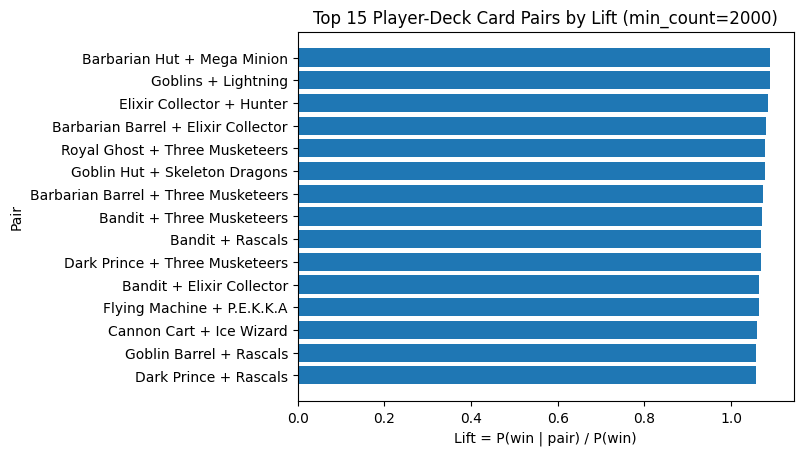

In [13]:
min_count = 2000 # tune-able threshold to filter out very rare pairs with high variance
pair_total = Counter()
pair_wins = Counter()

# iterate over training set only to avoid data leakage
for cards, y in zip(train_df["cards.p"], train_df["y"]):
    if not isinstance(cards, (list, tuple)) or len(cards) < 2:
        continue
    # sort to keep pairs consistent
    for a, b in itertools.combinations(sorted(cards), 2):
        pair_total[(a, b)] += 1
        pair_wins[(a, b)] += int(y)

baseline = float(train_df["y"].mean())

#Calculate lift (model effectiveness of pairs vs baseline win rate)
rows = []
for (a, b), cnt in pair_total.items():
    if cnt < min_count:
        continue
    wr = pair_wins[(a, b)] / cnt
    lift = wr / baseline if baseline > 0 else np.nan
    rows.append((a, b, cnt, wr, lift))

pair_df = (pd.DataFrame(rows, columns=["cardA_id", "cardB_id", "count", "win_rate", "lift"])
             .sort_values(["lift", "count"], ascending=[False, False])
             .reset_index(drop=True))

# Map IDs to names
if "id_to_name" in globals() and isinstance(id_to_name, dict):
    pair_df["cardA"] = pair_df["cardA_id"].map(id_to_name).fillna(pair_df["cardA_id"].astype(str))
    pair_df["cardB"] = pair_df["cardB_id"].map(id_to_name).fillna(pair_df["cardB_id"].astype(str))
else:
    pair_df["cardA"] = pair_df["cardA_id"].astype(str)
    pair_df["cardB"] = pair_df["cardB_id"].astype(str)

print(f"\nTop 25 high-lift pairs (min_count={min_count}) in PLAYER decks:")
display(pair_df[["cardA", "cardB", "count", "win_rate", "lift"]].head(25))

#Rarity + strength score: lift / support, where lift = P(win | pair) / P(win) 
#and support = count / # of training rows
n_rows = len(train_df)
pair_df["support"] = pair_df["count"] / n_rows
eps = 1e-9
pair_df["unconventional_score"] = pair_df["lift"] / (pair_df["support"] + eps)

print("\nTop 25 by unconventional_score (rare + strong)")
display(pair_df[["cardA", "cardB", "count", "support", "win_rate", "lift", "unconventional_score"]].head(25))

#Visualize top-lift pairs 
top_pairs_plot = pair_df.head(15).iloc[::-1]
labels = (top_pairs_plot["cardA"].astype(str) + " + " + top_pairs_plot["cardB"].astype(str))

plt.figure()
plt.barh(labels, top_pairs_plot["lift"])
plt.title(f"Top 15 Player-Deck Card Pairs by Lift (min_count={min_count})")
plt.xlabel("Lift = P(win | pair) / P(win)")
plt.ylabel("Pair")
plt.show()

**Visualizations of Model Comparison**

/opt/anaconda3/envs/clashml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model comparison on test set:


,model,accuracy,f1,auc
0,Dummy (majority),0.500000,0.000000,NaN
1,Logistic Regression,0.570420,0.570401,0.605420
2,XGBoost,0.596536,0.596485,0.637508


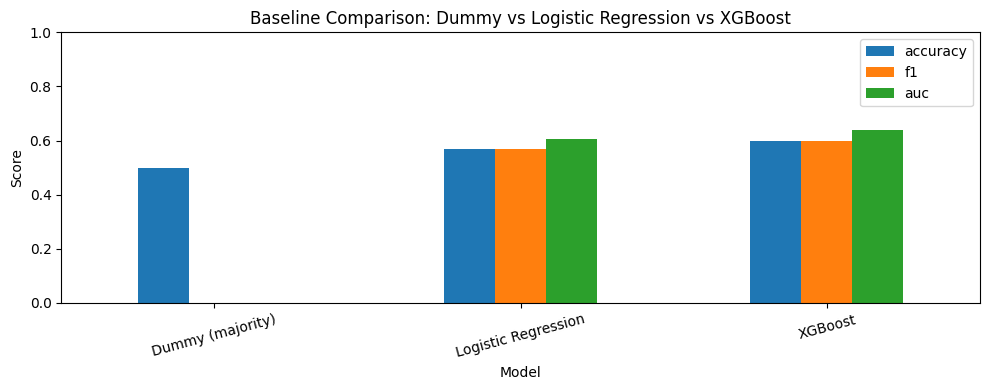

In [16]:
# Baseline 1: always predict majority class
majority_dummy = DummyClassifier(strategy="most_frequent")
majority_dummy.fit(X_train, y_train)
dummy_pred = majority_dummy.predict(X_test)

# Baseline 2: simple linear model on same preprocessed features
log_reg_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=500, n_jobs=-1, random_state=1)),
])
log_reg_pipe.fit(X_train, y_train)
lr_pred = log_reg_pipe.predict(X_test)
lr_proba = log_reg_pipe.predict_proba(X_test)[:, 1]

# Existing model metrics (XGBoost)
xgb_pred = pred
xgb_proba = proba

comparison = pd.DataFrame([
    {
        "model": "Dummy (majority)",
        "accuracy": accuracy_score(y_test, dummy_pred),
        "f1": f1_score(y_test, dummy_pred, zero_division=0),
        "auc": np.nan,
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, lr_pred),
        "f1": f1_score(y_test, lr_pred, zero_division=0),
        "auc": roc_auc_score(y_test, lr_proba),
    },
    {
        "model": "XGBoost",
        "accuracy": accuracy_score(y_test, xgb_pred),
        "f1": f1_score(y_test, xgb_pred, zero_division=0),
        "auc": roc_auc_score(y_test, xgb_proba),
    },
])

print("Model comparison on test set:")
display(comparison)

# Plot side-by-side bars for presentation
plot_df = comparison.set_index("model")[["accuracy", "f1", "auc"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4))
ax.set_title("Baseline Comparison: Dummy vs Logistic Regression vs XGBoost")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Expanded Evaluation and Error Analysis
These diagnostics support rubric sections on results interpretation and deeper analysis.


XGBoost evaluation metrics:


,accuracy,precision,recall,f1,auc
0,0.596536,0.59656,0.596411,0.596485,0.637508


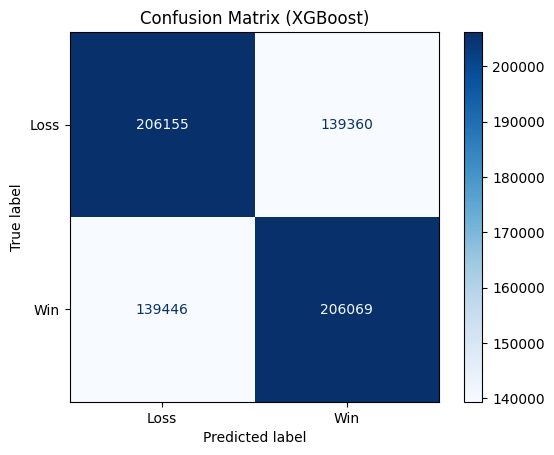

In [ ]:
metrics_df = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
    "auc": roc_auc_score(y_test, proba),
}])

print("XGBoost evaluation metrics:")
display(metrics_df)

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss", "Win"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (XGBoost)")
plt.show()


,confidence_bin,accuracy,n
0,"(-0.001, 0.1]",0.981524,866
1,"(0.1, 0.2]",0.863346,3132
2,"(0.2, 0.3]",0.769979,20759
3,"(0.3, 0.4]",0.664814,71626
4,"(0.4, 0.5]",0.557741,249218
5,"(0.5, 0.6]",0.557831,249122
6,"(0.6, 0.7]",0.664251,71354
7,"(0.7, 0.8]",0.770843,21230
8,"(0.8, 0.9]",0.871280,2890
9,"(0.9, 1.0]",0.985594,833


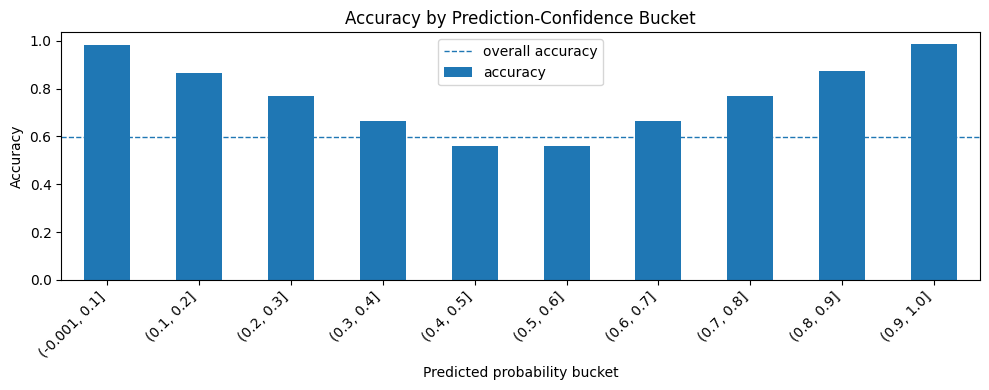

In [ ]:
analysis_df = test_df.copy()
analysis_df["pred"] = pred
analysis_df["proba"] = proba
analysis_df["correct"] = (analysis_df["pred"] == analysis_df["y"]).astype(int)

analysis_df["confidence_bin"] = pd.cut(
    analysis_df["proba"],
    bins=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

conf_perf = (
    analysis_df.groupby("confidence_bin", observed=False)
    .agg(accuracy=("correct", "mean"), n=("y", "size"))
    .reset_index()
)

display(conf_perf)

ax = conf_perf.plot(x="confidence_bin", y="accuracy", kind="bar", figsize=(10, 4), legend=False)
ax.axhline(analysis_df["correct"].mean(), linestyle="--", linewidth=1, label="overall accuracy")
ax.set_title("Accuracy by Prediction-Confidence Bucket")
ax.set_xlabel("Predicted probability bucket")
ax.set_ylabel("Accuracy")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
err_df = analysis_df.copy()
err_df["error_type"] = "correct"
err_df.loc[(err_df["y"] == 0) & (err_df["pred"] == 1), "error_type"] = "FP"
err_df.loc[(err_df["y"] == 1) & (err_df["pred"] == 0), "error_type"] = "FN"

def top_cards(rows, topn=15):
    c = Counter()
    for deck in rows["cards.p"]:
        if isinstance(deck, (list, tuple)):
            c.update(deck)
    out = (
        pd.DataFrame(c.items(), columns=["card", "count"])
        .sort_values("count", ascending=False)
        .head(topn)
    )
    return out

fp_cards = top_cards(err_df[err_df["error_type"] == "FP"])
fn_cards = top_cards(err_df[err_df["error_type"] == "FN"])

print("Top cards in False Positives")
display(fp_cards)
print("Top cards in False Negatives")
display(fn_cards)


Top cards in False Positives


,card,count
38,Zap,42002
27,Valkyrie,38473
12,The Log,36820
31,Wizard,36301
46,Fireball,34039
36,Skeleton Army,32130
56,Arrows,31729
41,Hog Rider,28901
47,Mega Knight,26993
21,Baby Dragon,25818


Top cards in False Negatives


,card,count
3,Wizard,43484
2,Valkyrie,43183
22,Zap,38739
34,The Log,37603
0,Fireball,36956
1,Skeleton Army,35078
31,Hog Rider,31677
49,Arrows,28787
8,Mega Knight,27367
12,Baby Dragon,23836


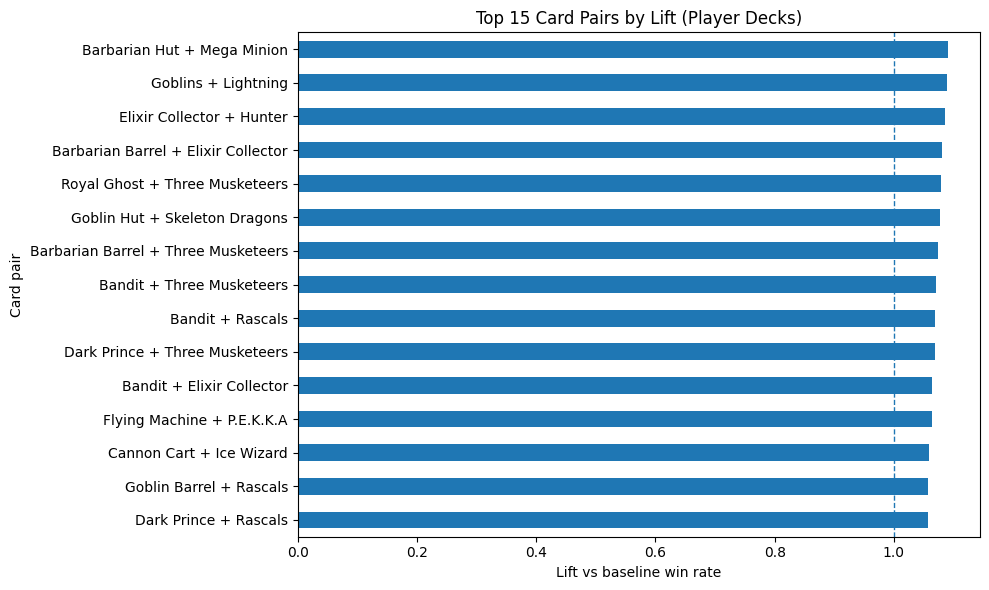

,pair,count,win_rate,lift
14,Dark Prince + Rascals,2889,0.528557,1.057113
13,Goblin Barrel + Rascals,17179,0.528727,1.057454
12,Cannon Cart + Ice Wizard,2649,0.529634,1.059268
11,Flying Machine + P.E.K.K.A,5560,0.531655,1.063309
10,Bandit + Elixir Collector,3038,0.531929,1.063858
9,Dark Prince + Three Musketeers,2504,0.534345,1.068690
8,Bandit + Rascals,2212,0.534810,1.069620
7,Bandit + Three Musketeers,4402,0.535666,1.071331
6,Barbarian Barrel + Three Musketeers,4007,0.536561,1.073122
5,Goblin Hut + Skeleton Dragons,2107,0.538681,1.077361


In [ ]:
# 3) Interaction insight: top high-lift card pairs with support shown
pairs_plot = pair_df.sort_values(["lift", "count"], ascending=[False, False]).head(15).copy()
pairs_plot["pair"] = pairs_plot["cardA"] + " + " + pairs_plot["cardB"]
pairs_plot = pairs_plot.iloc[::-1]

ax = pairs_plot.plot(x="pair", y="lift", kind="barh", figsize=(10, 6), legend=False)
ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_title("Top 15 Card Pairs by Lift (Player Decks)")
ax.set_xlabel("Lift vs baseline win rate")
ax.set_ylabel("Card pair")
plt.tight_layout()
plt.show()

display(pairs_plot[["pair", "count", "win_rate", "lift"]])


Best threshold by F1:


,threshold,accuracy,balanced_acc,precision,recall,f1
32,0.37,0.542554,0.542554,0.523498,0.948025,0.674525


Best threshold by Balanced Accuracy:


,threshold,accuracy,balanced_acc,precision,recall,f1
45,0.5,0.596536,0.596536,0.59656,0.596411,0.596485


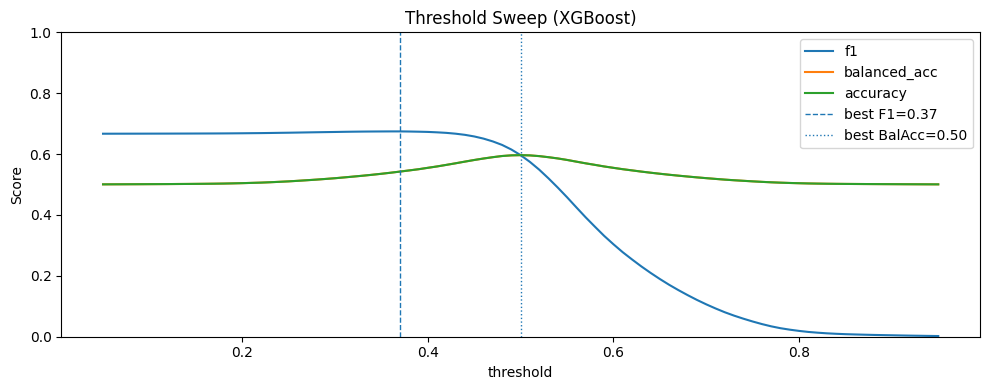

In [ ]:
# Threshold sweep for XGBoost probabilities (optimize F1 + Balanced Accuracy)

thresholds = np.arange(0.05, 0.96, 0.01)
rows = []

for t in thresholds:
    y_hat = (proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_hat),
        "balanced_acc": balanced_accuracy_score(y_test, y_hat),
        "precision": precision_score(y_test, y_hat, zero_division=0),
        "recall": recall_score(y_test, y_hat, zero_division=0),
        "f1": f1_score(y_test, y_hat, zero_division=0),
    })

thr_df = pd.DataFrame(rows)
best_f1 = thr_df.loc[thr_df["f1"].idxmax()]
best_bal = thr_df.loc[thr_df["balanced_acc"].idxmax()]

print("Best threshold by F1:")
display(best_f1.to_frame().T)
print("Best threshold by Balanced Accuracy:")
display(best_bal.to_frame().T)

ax = thr_df.plot(x="threshold", y=["f1", "balanced_acc", "accuracy"], figsize=(10, 4))
ax.axvline(best_f1["threshold"], linestyle="--", linewidth=1, label=f"best F1={best_f1['threshold']:.2f}")
ax.axvline(best_bal["threshold"], linestyle=":", linewidth=1, label=f"best BalAcc={best_bal['threshold']:.2f}")
ax.set_title("Threshold Sweep (XGBoost)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


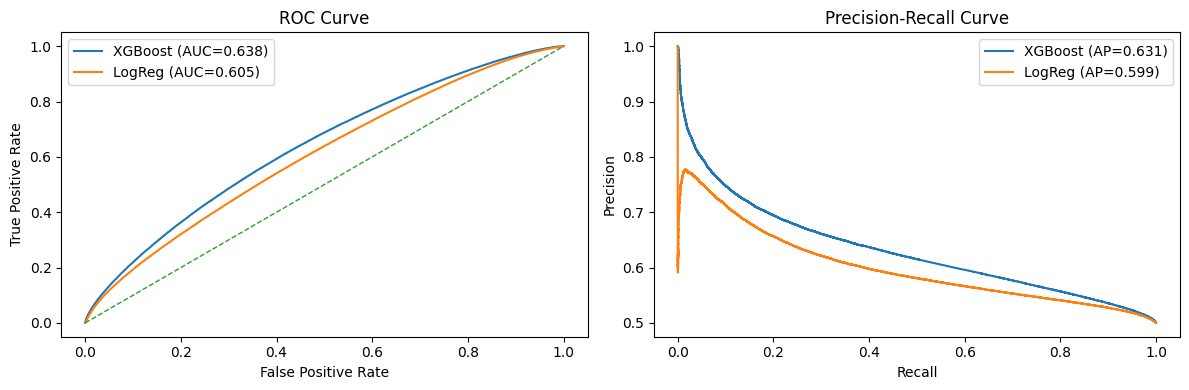

In [ ]:
# ROC + PR curves: Logistic Regression vs XGBoost
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# requires lr_proba from your logistic baseline cell
xgb_auc = roc_auc_score(y_test, proba)
lr_auc = roc_auc_score(y_test, lr_proba)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, proba)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_proba)

xgb_ap = average_precision_score(y_test, proba)
lr_ap = average_precision_score(y_test, lr_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC
axes[0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})")
axes[0].plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={lr_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR
axes[1].plot(rec_xgb, prec_xgb, label=f"XGBoost (AP={xgb_ap:.3f})")
axes[1].plot(rec_lr, prec_lr, label=f"LogReg (AP={lr_ap:.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

# Build analysis frame with predictions
err_df = test_df.copy()
err_df["y_true"] = y_test.values
err_df["y_pred"] = pred
err_df["proba_win"] = proba
err_df["error_type"] = "correct"
err_df.loc[(err_df["y_true"] == 0) & (err_df["y_pred"] == 1), "error_type"] = "FP"
err_df.loc[(err_df["y_true"] == 1) & (err_df["y_pred"] == 0), "error_type"] = "FN"

# Columns to inspect (kept robust if some cols don't exist)
candidate_cols = [
    "battleTime", "arena.id", "gameMode.id",
    "startingTrophies.p", "startingTrophies.o",
    "elixir.p", "elixir.o",
    "total_level.p", "total_level.o",
    "cards.p", "cards.o",
    "y_true", "y_pred", "proba_win", "error_type"
]
show_cols = [c for c in candidate_cols if c in err_df.columns]

# Most confident wrong predictions
top_fp = (
    err_df[err_df["error_type"] == "FP"]
    .sort_values("proba_win", ascending=False)
    .head(20)[show_cols]
)

top_fn = (
    err_df[err_df["error_type"] == "FN"]
    .sort_values("proba_win", ascending=True)  # very low proba but true win
    .head(20)[show_cols]
)

print("Top 20 False Positives (most confident wrong wins):")
display(top_fp)

print("Top 20 False Negatives (most confident missed wins):")
display(top_fn)


Top 20 False Positives (most confident wrong wins):


,battleTime,arena.id,gameMode.id,startingTrophies.p,startingTrophies.o,elixir.p,elixir.o,total_level.p,total_level.o,cards.p,cards.o,y_true,y_pred,proba_win,error_type
581960,2021-01-01 22:04:15+00:00,54000050.0,72000201.0,4973.0,4978.0,3.625,4.125000,104,86,"[Fireball, Bats, Zap, Goblin Gang, Ice Wizard,...","[Giant Skeleton, Electro Dragon, Bats, Zap, Wi...",0,1,0.968651,FP
671431,2021-01-01 23:11:33+00:00,54000050.0,72000201.0,4688.0,4690.0,3.500,4.000000,98,81,"[The Log, Zap, Minion Horde, Miner, Princess, ...","[Tombstone, Minions, Skeleton Army, Lava Hound...",0,1,0.928608,FP
483338,2021-01-01 21:12:26+00:00,54000050.0,72000201.0,4802.0,4801.0,3.000,5.750000,104,85,"[Hog Rider, Ice Golem, Tesla, Skeletons, Muske...","[Sparky, Balloon, Skeleton Dragons, Ram Rider,...",0,1,0.922412,FP
667086,2021-01-01 23:06:11+00:00,54000050.0,72000201.0,4416.0,4419.0,4.875,3.000000,85,67,"[Witch, Goblin Hut, Minion Horde, Mega Knight,...","[Wizard, Arrows, Hog Rider, Skeletons, Valkyri...",0,1,0.921863,FP
407165,2021-01-01 20:34:24+00:00,54000050.0,72000201.0,5084.0,5087.0,3.375,3.250000,104,89,"[Lightning, Hog Rider, The Log, Ice Spirit, Kn...","[Executioner, Tornado, Hog Rider, Knight, Gobl...",0,1,0.921004,FP
688421,2021-01-01 23:43:58+00:00,54000050.0,72000201.0,4778.0,4777.0,3.875,3.500000,102,83,"[Bomber, Baby Dragon, Minions, Mini P.E.K.K.A,...","[Cannon Cart, Skeleton Barrel, Goblin Gang, Ar...",0,1,0.914086,FP
449667,2021-01-01 20:55:53+00:00,54000050.0,72000201.0,4999.0,5000.0,3.000,4.375000,104,87,"[Cannon, Archers, Ice Spirit, Knight, Hog Ride...","[Golem, Night Witch, Prince, Bomber, Bats, Ske...",0,1,0.912530,FP
509695,2021-01-01 21:25:54+00:00,54000050.0,72000201.0,4807.0,4807.0,3.625,2.875000,103,83,"[Minions, Hog Rider, Knight, Valkyrie, Firebal...","[The Log, Dart Goblin, Knight, Skeletons, Gobl...",0,1,0.911830,FP
556698,2021-01-01 21:50:30+00:00,54000050.0,72000201.0,4662.0,4643.0,3.625,3.250000,95,80,"[Minions, Bomber, Skeleton Army, Knight, Valky...","[Giant Skeleton, Bats, Miner, Giant Snowball, ...",0,1,0.910341,FP
474676,2021-01-01 21:08:09+00:00,54000050.0,72000201.0,4735.0,4724.0,4.125,2.750000,100,85,"[The Log, Mother Witch, Inferno Dragon, Lightn...","[Electro Wizard, Hunter, Skeletons, Valkyrie, ...",0,1,0.910055,FP


Top 20 False Negatives (most confident missed wins):


,battleTime,arena.id,gameMode.id,startingTrophies.p,startingTrophies.o,elixir.p,elixir.o,total_level.p,total_level.o,cards.p,cards.o,y_true,y_pred,proba_win,error_type
236445,2021-01-01 22:04:15+00:00,54000050.0,72000201.0,4978.0,4973.0,4.125000,3.625,86,104,"[Giant Skeleton, Electro Dragon, Bats, Zap, Wi...","[Fireball, Bats, Zap, Goblin Gang, Ice Wizard,...",1,0,0.028881,FN
236877,2021-01-01 22:04:30+00:00,54000050.0,72000201.0,5539.0,5578.0,3.125000,2.750,91,104,"[Goblin Barrel, Dart Goblin, Knight, Princess,...","[Princess, The Log, Goblin Barrel, Dart Goblin...",1,0,0.075822,FN
61650,2021-01-01 20:34:24+00:00,54000050.0,72000201.0,5087.0,5084.0,3.250000,3.375,89,104,"[Executioner, Tornado, Hog Rider, Knight, Gobl...","[Lightning, Hog Rider, The Log, Ice Spirit, Kn...",1,0,0.076314,FN
328621,2021-01-01 23:15:08+00:00,54000050.0,72000201.0,4240.0,4228.0,2.839286,4.000,101,79,"[Earthquake, Skeletons, Mirror, Clone, Miner, ...","[Lumberjack, Goblin Barrel, Minions, Arrows, F...",1,0,0.078175,FN
321571,2021-01-01 23:06:11+00:00,54000050.0,72000201.0,4419.0,4416.0,3.000000,4.875,67,85,"[Wizard, Arrows, Hog Rider, Skeletons, Valkyri...","[Witch, Goblin Hut, Minion Horde, Mega Knight,...",1,0,0.079560,FN
137823,2021-01-01 21:12:26+00:00,54000050.0,72000201.0,4801.0,4802.0,5.750000,3.000,85,104,"[Sparky, Balloon, Skeleton Dragons, Ram Rider,...","[Hog Rider, Ice Golem, Tesla, Skeletons, Muske...",1,0,0.081957,FN
325916,2021-01-01 23:11:33+00:00,54000050.0,72000201.0,4690.0,4688.0,4.000000,3.500,81,98,"[Tombstone, Minions, Skeleton Army, Lava Hound...","[The Log, Zap, Minion Horde, Miner, Princess, ...",1,0,0.082637,FN
342906,2021-01-01 23:43:58+00:00,54000050.0,72000201.0,4777.0,4778.0,3.500000,3.875,83,102,"[Cannon Cart, Skeleton Barrel, Goblin Gang, Ar...","[Bomber, Baby Dragon, Minions, Mini P.E.K.K.A,...",1,0,0.083537,FN
129161,2021-01-01 21:08:09+00:00,54000050.0,72000201.0,4724.0,4735.0,2.750000,4.125,85,100,"[Electro Wizard, Hunter, Skeletons, Valkyrie, ...","[The Log, Mother Witch, Inferno Dragon, Lightn...",1,0,0.086747,FN
90741,2021-01-01 20:49:11+00:00,54000050.0,72000201.0,5087.0,5095.0,4.000000,3.750,90,104,"[Executioner, Hog Rider, Inferno Dragon, Knigh...","[Princess, Rascals, Goblin Barrel, The Log, Pr...",1,0,0.087294,FN
